In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [4]:
data = pd.read_excel("dataset.xlsx")
data.head()

,Unnamed: 0,id,name,artist,disc,duration,episode,explicit,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,time_signature,valence,lyrics
0,0,1hA4856JVAa0qqgKg6olJf,"The Messenger - Live from Las Vegas, 2011",Linkin Park,1,233280,False,False,37,0.325,0.726000,0.409,0.000013,0.1880,-5.711,1,0.0295,109.001,4,0.187,6 ContributorsThe Messenger (Live from Las Veg...
1,1,0GgN4MhR5GKn5IcKN0e0rG,Cancer,My Chemical Romance,1,142973,False,False,72,0.457,0.358000,0.515,0.000000,0.2780,-4.310,1,0.0261,74.984,4,0.222,93 ContributorsCancer Lyrics\nTurn away\nIf yo...
2,2,10nyNJ6zNy2YVYLrcwLccB,No Surprises,Radiohead,1,229120,False,False,83,0.255,0.057700,0.393,0.003610,0.1130,-10.654,1,0.0278,76.426,4,0.118,129 ContributorsTranslationsРусскийDeutschEspa...
3,3,7lRlq939cDG4SzWOF4VAnd,I'm Not Okay (I Promise),My Chemical Romance,1,186480,False,True,78,0.210,0.006020,0.940,0.000000,0.2690,-3.427,1,0.1230,179.722,4,0.255,109 ContributorsTranslationsEspañolI’m Not Oka...
4,4,5u2FOoFhp495GIj5BJC77J,Hold On Till May,Pierce The Veil,1,278586,False,False,66,0.460,0.000585,0.910,0.001550,0.0735,-3.710,1,0.0525,73.019,4,0.327,58 ContributorsHold on Till May Lyrics\nShe si...


In [5]:
from sklearn.preprocessing import StandardScaler
VARS = ["duration","popularity","danceability","energy","liveness"]
x = data[VARS]

esc = StandardScaler()

x_esc = esc.fit_transform(x)
x_cent = x_esc - np.mean(x_esc, axis = 0)


In [6]:
n = x_cent.shape[0]
(x_cent.T @ x_cent)/(n-1)

array([[ 1.00096805, -0.00933217, -0.30396724, -0.07603977,  0.05345157],
       [-0.00933217,  1.00096805,  0.23549008,  0.64023109,  0.02485663],
       [-0.30396724,  0.23549008,  1.00096805,  0.30190071, -0.070584  ],
       [-0.07603977,  0.64023109,  0.30190071,  1.00096805,  0.14388091],
       [ 0.05345157,  0.02485663, -0.070584  ,  0.14388091,  1.00096805]])

In [7]:
n_components = 2
x_cov = np.cov(x_cent, rowvar=False, bias = False)
eigenvalues, eigenvectors = np.linalg.eig(x_cov)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

#Explained_variance_ratio

print(np.sum(eigenvalues[:n_components])/ np.sum(eigenvalues))
x_pca = np.dot(x_cent, eigenvectors)
x_pca = x_pca[:,:n_components]
x_pca

0.6161597937089374


array([[-0.75323659,  0.5841749 ],
       [ 0.76294971,  0.28146014],
       [-0.16106238,  0.84451019],
       ...,
       [ 2.12521392, -0.58607359],
       [ 2.64732834, -0.68228857],
       [ 1.22418975, -0.40672546]], shape=(1034, 2))

In [8]:
# The most difficult part of the job

from sklearn.decomposition import PCA
pca = PCA(n_components=2)


pca.fit_transform(x_esc)
print(np.sum(pca.explained_variance_ratio_))

0.6161597937089375


In [9]:
eigenvectors

array([[-0.21591904,  0.65152568, -0.44718178, -0.57174524, -0.04504537],
       [ 0.59246366,  0.26082651, -0.28152459,  0.24119928,  0.66597534],
       [ 0.4509878 , -0.44911185,  0.091522  , -0.76067982,  0.08887342],
       [ 0.62760034,  0.24423677, -0.04966723,  0.13724555, -0.72468133],
       [ 0.07136937,  0.49611568,  0.84257299, -0.1321369 ,  0.14624036]])

In [10]:
loadings = pca.components_.T

In [11]:
data.sort_values("energy", ascending=False).head(10)

,Unnamed: 0,id,name,artist,disc,duration,episode,explicit,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,time_signature,valence,lyrics
127,42,6eN1f9KNmiWEhpE2RhQqB5,Paradise City,Guns N' Roses,1,405600,False,True,82,0.268,0.019200,0.980,0.007090,0.182,-5.958,1,0.1030,100.315,4,0.395,60 ContributorsParadise City Lyrics\nTake me d...
776,24,0BjjbjGfrUk4mSAM0LtC7L,Ya Need It,Hot for Crime,1,165026,False,False,53,0.514,0.000017,0.976,0.000120,0.358,-2.211,1,0.0759,124.967,4,0.544,2 ContributorsEveryday Hustle Lyrics\nRupsha o...
209,124,4Clmg1g8n2yBYG13Z1oSdG,Baila Conmigo (feat. Kelly Ruiz),Dayvi,1,189817,False,False,69,0.745,0.009030,0.972,0.465000,0.297,-3.506,1,0.0774,128.031,4,0.556,8 ContributorsBaila Conmigo Lyrics\n\nImagínat...
878,126,2kWfIfVahndPcowzt13TKu,Sweetness,Wolves At The Gate,1,219141,False,False,47,0.421,0.000035,0.970,0.001580,0.389,-3.511,1,0.1150,134.961,4,0.415,3 ContributorsSweetness Lyrics\nIf you're list...
138,53,6PwjJ58I4t7Mae9xfZ9l9v,Somebody Told Me,The Killers,1,197200,False,False,81,0.497,0.000090,0.970,0.000674,0.101,-4.851,0,0.0836,138.081,4,0.689,90 ContributorsSomebody Told Me Lyrics\nBreaki...
166,81,1f2V8U1BiWaC9aJWmpOARe,By the Way,Red Hot Chili Peppers,1,216933,False,False,77,0.451,0.026400,0.970,0.003550,0.102,-4.938,1,0.1070,122.444,4,0.198,54 ContributorsBy the Way Lyrics\nStanding in ...
88,3,4uUG5RXrOk84mYEfFvj3cK,I'm Good (Blue),David Guetta,1,175238,False,True,91,0.561,0.003830,0.965,0.000007,0.371,-3.673,0,0.0343,128.040,4,0.304,54 ContributorsTranslationsPortuguêsEspañolTür...
188,103,2LCd6P35jFyZ9SN37o9D2q,Drinkin',Joel Corry,1,149545,False,False,73,0.716,0.034400,0.963,0.000000,0.292,-3.097,0,0.0931,124.970,4,0.707,"8 ContributorsDrinkin’ Lyrics\nAll night, I've..."
190,105,0vR2rIVORmgeKiGIgNT0fV,By Your Side (feat. Tom Grennan),Calvin Harris,1,189671,False,False,73,0.733,0.051400,0.960,0.001990,0.287,-3.597,1,0.0295,124.010,4,0.811,1 ContributorToday’s Top Hits 7/9/21 (feat. Po...
57,32,5xC8uOesnn0udeXAYlAnoY,Alright,Supergrass,1,180880,False,False,75,0.467,0.000479,0.958,0.199000,0.299,-4.808,0,0.0775,145.920,4,0.701,"34 ContributorsAlright Lyrics\nWe are young, w..."


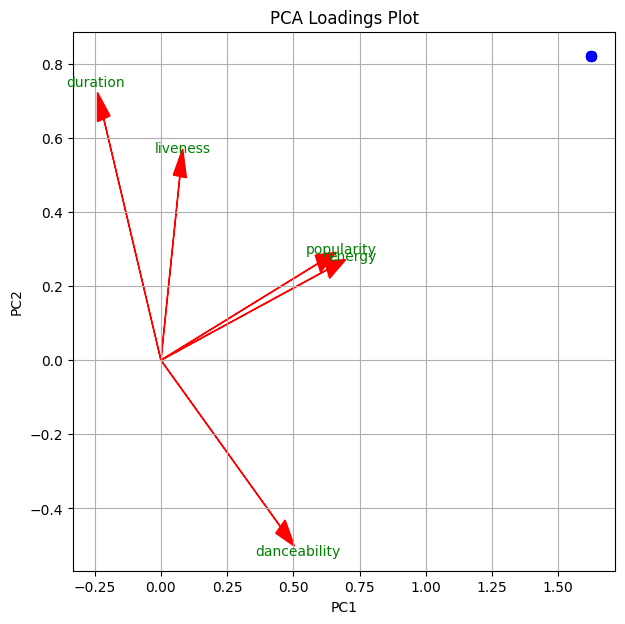

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, feature in enumerate(VARS):
    # Plot arrow from origin to loading coordinates
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', head_width=0.05, length_includes_head=False)
    # Label the arrow with the feature name
    ax.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, feature, color='g', ha='center', va='center')
    ax.scatter(x_pca[776,0], x_pca[776,1], color='b', s=50)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Loadings Plot")
ax.grid()
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()

In [15]:
import cv2
import requests

In [16]:
url = "https://en.dragon-ball-official.com/dragonball/jp/news/2025/02/SHF_SS4mini01.JPG"
res = requests.get(url)
arr = np.frombuffer(res.content, np.uint8)
goku = cv2.imdecode(arr, cv2.IMREAD_COLOR)
goku.shape

(1920, 1536, 3)

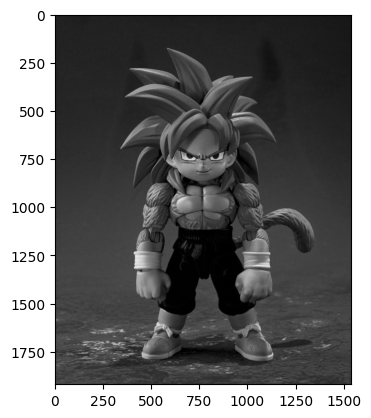

In [17]:
n, k, b = goku.shape

goku_new = goku[:,:,0]

plt.imshow(goku_new, cmap="gray")

In [18]:
from pylab import *
print(goku_new.shape)
U, S, Vt = np.linalg.svd(goku_new)
U.shape
S2 = resize(S,(n,1))* eye(n,k)


(1920, 1536)


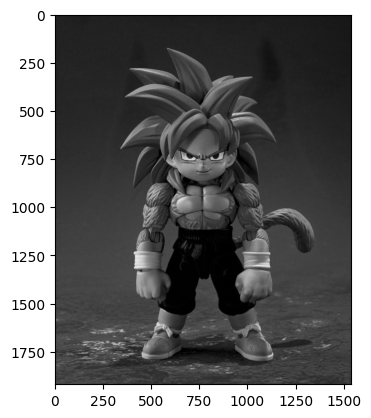

In [19]:
plt.imshow(np.dot(U, np.dot(S2, Vt)), cmap="gray")

In [20]:
print(U.shape)
print(S2.shape)
print(Vt.shape)

(1920, 1920)
(1920, 1536)
(1536, 1536)


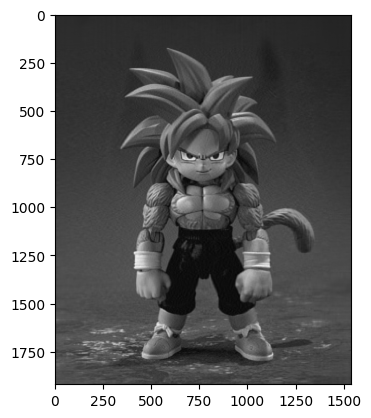

In [21]:
k = 100
plt.imshow(np.dot(U[:,0:k], np.dot(S2[0:k,0:k],Vt[0:k,:])), cmap="gray")